# RGB color transfer by a Monge map

This notebook generates `fig:monge-color-transfer-rgb`.  The beach and flower photographs from `assets/` define empirical color laws in the RGB cube.  We sample two equal-size palettes,
$$
\alpha_n=\frac1n\sum_i\delta_{c_i},\qquad
\beta_n=\frac1n\sum_j\delta_{d_j},
$$
solve the quadratic optimal assignment in RGB space with POT, and extend the resulting discrete map to all source pixels by nearest-neighbor interpolation in color space.

In [1]:
from pathlib import Path
import sys

for candidate in [Path.cwd(), Path.cwd() / "notebooks-figures", Path.cwd().parent / "notebooks-figures"]:
    if (candidate / "figure_style.py").exists():
        sys.path.insert(0, str(candidate.resolve()))
        ROOT = candidate.parent if candidate.name == "notebooks-figures" else candidate
        break
else:
    raise RuntimeError("Could not locate figure_style.py")

import matplotlib.pyplot as plt
import numpy as np
import ot
from PIL import Image
from scipy.spatial import cKDTree

from figure_style import figure_dir, interp_color, remove_axes, save_pdf, setup_matplotlib

setup_matplotlib()
rng = np.random.default_rng(20240608)
ASSETS = ROOT / "notebooks-figures" / "assets"


## Palette transport

The OT problem is intentionally small, but the resulting color map is applied to the full downsampled image.  Interpolation in RGB gives a smooth visual transition
$c_t=(1-t)c+tT(c)$.

In [2]:
def load_rgb(name, n=86):
    img = Image.open(ASSETS / name).convert("RGB")
    img = img.resize((n, n), Image.Resampling.LANCZOS)
    return np.asarray(img, dtype=float) / 255.0

source = load_rgb("beach.jpg")
target = load_rgb("flower.jpg")
source_pixels = source.reshape(-1, 3)
target_pixels = target.reshape(-1, 3)

n_palette = 190
src_idx = rng.choice(len(source_pixels), size=n_palette, replace=False)
tgt_idx = rng.choice(len(target_pixels), size=n_palette, replace=False)
src_palette = source_pixels[src_idx]
tgt_palette = target_pixels[tgt_idx]

a = np.ones(n_palette) / n_palette
b = np.ones(n_palette) / n_palette
C = ot.dist(src_palette, tgt_palette, metric="sqeuclidean")
P = ot.emd(a, b, C, numItermax=200000)
T_palette = (P @ tgt_palette) / a[:, None]

nearest = cKDTree(src_palette).query(source_pixels, k=1)[1]
mapped_pixels = T_palette[nearest]
mapped = mapped_pixels.reshape(source.shape)

times = [0.0, 1/3, 2/3, 1.0]
images = [(1 - t) * source + t * mapped for t in times] + [target]
clouds = [(1 - t) * src_palette + t * T_palette for t in times] + [tgt_palette]


## Exported image and RGB-cloud panels

The PDFs contain no titles or axes.  LaTeX supplies the time labels and explains that only colors, not pixel locations, are transported.

In [3]:
NAME = "monge-color-transfer-rgb"
OUT = figure_dir(NAME)
labels = ["t000", "t033", "t067", "t100", "target"]

for label, img in zip(labels, images):
    fig, ax = plt.subplots(figsize=(1.18, 1.18))
    ax.imshow(np.clip(img, 0, 1), interpolation="nearest")
    remove_axes(ax)
    save_pdf(fig, OUT / f"image-{label}.pdf", pad_inches=0.01)
    plt.close(fig)

for label, cloud in zip(labels, clouds):
    fig = plt.figure(figsize=(1.18, 1.18))
    ax = fig.add_subplot(111, projection="3d")
    ax.scatter(cloud[:, 0], cloud[:, 1], cloud[:, 2], s=5, c=np.clip(cloud, 0, 1), depthshade=False, linewidth=0)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_zlim(0, 1)
    ax.view_init(elev=18, azim=-58)
    ax.set_axis_off()
    save_pdf(fig, OUT / f"rgb-{label}.pdf", pad_inches=0.00)
    plt.close(fig)


## Figure preview

The output below embeds the current generated thumbnail so the figure renders directly on GitHub.


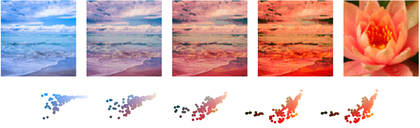

In [4]:
from pathlib import Path
from IPython.display import Image, display
_thumb = Path("thumbnails/monge-color-transfer-rgb.png")
if not _thumb.exists():
    _thumb = Path("notebooks-figures/thumbnails/monge-color-transfer-rgb.png")
display(Image(filename=str(_thumb)))
